# S2 Human Study Results
Reads all `evaluation/humans/by_participant/*.json`, filters to participants with
`>= MIN_ANSWERS` answers, then restricts to the **intersection** of question IDs
across all qualifying participants.

In [1]:
!python /home/david/Desktop/yuna/HPA/evaluation/humans/export_participants.py --delete-source-files

Loaded participant records: 13
Unique participant codes: 13
Duplicate participant codes: 0
Wrote files: 13
  /home/david/Desktop/yuna/HPA/evaluation/humans/by_participant/0430_30목_0S9EIHUY_주수진_402.json <- participants_13_2026-05-12.json (402 answers)
  /home/david/Desktop/yuna/HPA/evaluation/humans/by_participant/0507_may_1UB7WNAM_정재현_402.json <- participants_13_2026-05-12.json (402 answers)
  /home/david/Desktop/yuna/HPA/evaluation/humans/by_participant/0507_may_3BN3ZBUX_류지승_402.json <- participants_13_2026-05-12.json (402 answers)
  /home/david/Desktop/yuna/HPA/evaluation/humans/by_participant/0507_may_85M7GIDP_한지윤_402.json <- participants_13_2026-05-12.json (402 answers)
  /home/david/Desktop/yuna/HPA/evaluation/humans/by_participant/0428_28_화_DYAN3RF8_표서윤_402.json <- participants_13_2026-05-12.json (402 answers)
  /home/david/Desktop/yuna/HPA/evaluation/humans/by_participant/0507_may_EN84KWE9_이가현_402.json <- participants_13_2026-05-12.json (402 answers)
  /home/david/Desktop/yuna/H

In [2]:
import re
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from collections import defaultdict

BASE = Path('/home/david/Desktop/yuna/HPA')
sys.path.insert(0, str(BASE / 'analysis'))  # must come before utils imports

from utils.vqa import VQAAnswerMapper, vqa_accuracy
from utils.constants import VARIANT_ORDER, VARIANT_LABELS, VARIANT_COLORS
mapper = VQAAnswerMapper()

sns.set_theme(style='whitegrid', font_scale=1.1)

import re as _re
from utils.load_session import clean_answer as _clean_answer 
import importlib, utils.load_session
importlib.reload(utils.load_session)
from utils.load_session import backfill_question_text

backfill_question_text(BASE, s2_version='s2_v4')


Loaded question text lookup: 402 entries from s2_v4

Backfilled question_en/question_kr on 0 rows across 0/36 participant files


In [3]:
# ── Load human data (participants → translate → flatten → intersect) ──────────
from utils.load_session import load_human_data, check_translation_coverage

MIN_ANSWERS = 348
participants, common_qids, df, mapper = load_human_data(BASE, min_answers=MIN_ANSWERS)
check_translation_coverage(df, BASE / 'analysis/utils/kr_answer_map.json')

print(f'\ndf shape: {df.shape}')
df.head(3)[['participant','variant','answer_kr','answer_en','gt','accuracy']]

Qualifying participants (>= 348 answers): 36
  0S9EIHUY  answers=402  qids=134
  0X4B4L3T  answers=402  qids=134
  1UB7WNAM  answers=402  qids=134
  3BN3ZBUX  answers=402  qids=134
  85M7GIDP  answers=402  qids=134
  8HLCRUY1  answers=348  qids=116
  BEK0Y4W3  answers=402  qids=134
  BTTWUQG4  answers=402  qids=134
  DPCN9S37  answers=348  qids=116
  DYAN3RF8  answers=402  qids=134
  EN84KWE9  answers=402  qids=134
  FG80C8QR  answers=402  qids=134
  FLWP3ZF7  answers=348  qids=116
  FXDCPFHM  answers=402  qids=134
  FYXQSR7I  answers=402  qids=134
  HB857QDA  answers=348  qids=116
  HGIX7HE0  answers=402  qids=134
  IM2K4RKB  answers=402  qids=134
  IR1A0UYG  answers=402  qids=134
  IV0PL083  answers=402  qids=134
  J09HHJXK  answers=348  qids=116
  J0OU3FTE  answers=372  qids=124
  JOJCF28V  answers=372  qids=124
  K8VD3TYB  answers=348  qids=116
  MPOMQQNU  answers=348  qids=116
  NFZJ7A7N  answers=402  qids=134
  NVF556XP  answers=348  qids=116
  O23790AV  answers=348  qids=116
  O

/home/david/miniconda3/envs/aide/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Raw Korean strings      : 2690
Already translated      : 2085
Unique canonicals to translate: 603

Sample canonical forms:
  '팀장'                       (q: "What is the person's position called?")
  '생일 축하 케이크'                (q: 'What does the cake represent?')
  '일반 컴퓨터'                   (q: 'What type of computer is the cat using?')
  '야채'                       (q: 'What is in this sandwich?')
  '핸들'                       (q: 'What is orange on the vehicle?')
  '테이블 아래'                   (q: 'What location is the luggage at?')
  '진한 자주색'                   (q: 'What color of wine is in the glasses?')
  '주스'                       (q: 'What kind of drink is in the glasses?')


Translating: 100%|██████████| 603/603 [07:53<00:00,  1.27it/s]



✓ Translated 603 canonical strings → /home/david/Desktop/yuna/HPA/analysis/utils/kr_answer_map.json
   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations

Common question_ids: 113
Rows: 12204 | questions: 113 | participants: 36
Answers still in Korean (scored 0): 0 / 12204 (0.0%)
Total     : 12204
Translated: 12204  (100.0%)
Untranslated: 0  (0.0%)
✓ All answers translated.

df shape: (12204, 19)


,participant,variant,answer_kr,answer_en,gt,accuracy
0,HB857QDA,A,yes,yes,"[yes, yes, yes, yes, yes, yes, yes, yes, yes, ...",1.0
1,HB857QDA,A,과일들,fruits,"[chicken, veggies, plate, veggies, veggies, ve...",0.0
2,HB857QDA,A,오리엔탈 소스,oriental sauce,"[mustard, ketchup, ketchup and mustard, ketchu...",0.0


In [4]:
# ── Load model results (inst_blind) ──────────────────────────────────────────
from utils.load_session import load_model_results, VARIANT_ORDER

q_ids = set(df['question_id'].tolist())
model_q_acc, MODEL_TYPE, MODELS, ALL_MODELS = load_model_results(BASE, q_ids)

   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
Loaded vqa_1k_control_inst_blind for: ['Qwen3-VL-8B', 'LLaVA-1.5-7B', 'LLaVA-Mistral', 'LLaVA-Vicuna', 'InternVL-1B', 'InternVL-2B', 'InternVL-8B', 'LLaVA-1.5 (LM)', 'LLaVA-Mistral (LM)', 'LLaVA-Vicuna (LM)', 'Qwen3-0.6B', 'Qwen3-1.7B', 'Qwen3-4B', 'Qwen3-8B', 'Qwen3-32B', 'Mistral-7B', 'Vicuna-13B', 'Qwen2.5-7B', 'Phi-3.5-mini']
  [VLM         ] Qwen3-VL-8B: 112 questions, mean C = 0.473
  [VLM         ] LLaVA-1.5-7B: 113 questions, mean C = 0.472
  [VLM         ] LLaVA-Mistral: 113 questions, mean C = 0.537
  [VLM         ] LLaVA-Vicuna: 113 questions, mean C = 0.516
  [VLM         ] InternVL-1B: 112 questions, mean C = 0.369
  [VLM         ] InternVL-2B: 113 questions, mean C = 0.445
  [VLM         ] InternVL-8B: 113 questions, mean C = 0.372
  [VLM backbone decoder] LLaVA-1.5 (LM): 113 questions, mean C = 0.537
  [VLM backbone decoder] LLaVA-Mistral

In [5]:
# ── Export: separate human and model response files ──────────────────────────
# Human: responses_human.csv  — one row per (question_id, variant, participant)
# Model: responses_model_{condition}.csv — one row per (question_id, variant, model)
#        conditions: control | blind | inst_blind  (inst_blind = primary)
#
# Variant name mapping in logit files:
#   'question' → C  |  'weaker_object' → B  |  'pronominalized' → A

from utils.normalize_korean import clean_korean_answer
from utils.load_session import clean_answer as _clean_answer

if 'model_q_acc' not in dir(): model_q_acc = {}
if 'MODEL_TYPE'  not in dir(): MODEL_TYPE = {}
# Rebuild MODELS from ALL_MODELS if missing or empty
if 'MODELS' not in dir() or not MODELS:
    if 'ALL_MODELS' in dir():
        MODELS = {label: rdir / mdir for label, (rdir, mdir) in ALL_MODELS.items()}
    else:
        raise RuntimeError('Run cell 25 (model loading) before this cell')

OUT = BASE / 'analysis/session2/exports'
OUT.mkdir(exist_ok=True)

CT_MAP   = {'question': 'C', 'weaker_object': 'B', 'pronominalized': 'A'}
COND_MAP = {                          # condition suffix → readable name
    'vqa_1k_control':            'control',
    'vqa_1k_control_blind':      'blind',
    'vqa_1k_control_inst_blind': 'inst_blind',
}

# ── Shared lookups ────────────────────────────────────────────────────────────
meta   = df[['question_id','ent','op']].drop_duplicates('question_id').set_index('question_id')
gt_map = {qid: ' | '.join(mapper.get_answers(qid) or []) for qid in common_qids}

q_en_map, q_kr_map = {}, {}
for p in participants:
    for a in p['answers']:
        key = (a['question_id'], a.get('variant', 'C'))
        if key not in q_en_map:
            q_en_map[key] = a.get('question_en', '')
            q_kr_map[key] = a.get('question_kr', '')

# Human avg accuracy per (qid, variant)
h_avg = (df.groupby(['question_id', 'variant'])['accuracy']
           .mean().rename('human_avg_acc').reset_index())

# Model avg accuracy per (qid, variant) across all models
model_avg_rows = []
for label, mdf in model_q_acc.items():
    for var in VARIANT_ORDER:
        for qid, acc in mdf[var].items():
            if not np.isnan(acc) and qid in common_qids:
                model_avg_rows.append({'question_id': qid, 'variant': var, 'acc': acc})
m_avg = (pd.DataFrame(model_avg_rows).groupby(['question_id', 'variant'])['acc']
           .mean().rename('model_avg_acc').reset_index()
         if model_avg_rows else
         pd.DataFrame(columns=['question_id', 'variant', 'model_avg_acc']))

def add_meta(df_in):
    df_in = df_in.merge(meta.reset_index(), on='question_id', how='left')
    df_in['gt'] = df_in['question_id'].map(gt_map)
    return df_in

# ════════════════════════════════════════════════════════════════════════════════
# ── HUMAN FILE ────────────────────────────────────────────────────────────────
# ════════════════════════════════════════════════════════════════════════════════
hrows = df[['question_id', 'variant', 'participant', 'answer_kr', 'answer_en', 'accuracy']].copy()
hrows = hrows.merge(h_avg, on=['question_id', 'variant'], how='left')
hrows = hrows.merge(m_avg, on=['question_id', 'variant'], how='left')
hrows['canonical_kr'] = hrows['answer_kr'].apply(clean_korean_answer)
hrows['response']     = hrows['answer_en']
hrows['question_en']  = hrows.apply(lambda r: q_en_map.get((r.question_id, r.variant), ''), axis=1)
hrows['question_kr']  = hrows.apply(lambda r: q_kr_map.get((r.question_id, r.variant), ''), axis=1)
hrows = add_meta(hrows)
hrows = hrows[['question_id', 'ent', 'op', 'variant', 'question_en', 'question_kr', 'gt',
               'human_avg_acc', 'model_avg_acc',
               'participant', 'accuracy', 'answer_kr', 'canonical_kr', 'response']]
hrows = hrows.sort_values(['question_id', 'variant', 'participant']).reset_index(drop=True)

hpath = OUT / 'responses_human.csv'
hrows.to_csv(hpath, index=False)
print(f'Human  → {hpath}  ({len(hrows)} rows, {hrows.participant.nunique()} participants)')

# ════════════════════════════════════════════════════════════════════════════════
# ── MODEL FILES (one per condition) ───────────────────────────────────────────
# ════════════════════════════════════════════════════════════════════════════════
for jsonl_key, cond_name in COND_MAP.items():
    mrows_list = []
    for label, mdf in model_q_acc.items():
        path = MODELS[label] / f'{jsonl_key}.jsonl'
        if not path.exists():
            # lm_decoder models have no vqa_1k_control (text-only, blind is their baseline)
            is_lm = 'lm_decoder' in str(MODELS[label])
            if jsonl_key == 'vqa_1k_control' and is_lm:
                continue   # expected — skip silently
            print(f'  MISSING {label} / {jsonl_key}.jsonl')
            continue
        ans_map = {}
        for line in open(path):
            ex  = json.loads(line)
            qid = int(ex['question_id'])
            if qid not in common_qids: continue
            ga  = ex.get('generated_answers', {})
            for ct, var in CT_MAP.items():
                raw = ga.get(ct, '')
                if raw:
                    ans_map[(qid, var)] = _clean_answer(raw)

        for var in VARIANT_ORDER:
            for qid in common_qids:
                acc = mdf[var].get(qid, np.nan)
                if np.isnan(acc): continue
                mrows_list.append({
                    'question_id': qid,
                    'variant':     var,
                    'model':       label,
                    'model_group': MODEL_TYPE.get(label, ''),
                    'accuracy':    acc,
                    'response':    ans_map.get((qid, var), ''),
                    'question_en': q_en_map.get((qid, var), ''),
                    'question_kr': q_kr_map.get((qid, var), ''),
                })

    if not mrows_list:
        print(f'  [{cond_name}] no model rows — skipping')
        continue

    mrows = pd.DataFrame(mrows_list)
    mrows = mrows.merge(h_avg, on=['question_id', 'variant'], how='left')
    mrows = mrows.merge(m_avg, on=['question_id', 'variant'], how='left')
    mrows = add_meta(mrows)
    mrows = mrows[['question_id', 'ent', 'op', 'variant', 'question_en', 'question_kr', 'gt',
                   'human_avg_acc', 'model_avg_acc',
                   'model', 'model_group', 'accuracy', 'response']]
    mrows = mrows.sort_values(['question_id', 'variant', 'model_group', 'model']).reset_index(drop=True)

    mpath = OUT / f'responses_model_{cond_name}.csv'
    mrows.to_csv(mpath, index=False)
    print(f'Model [{cond_name}] → {mpath}  ({len(mrows)} rows, {mrows.model.nunique()} models)')

hrows.head(3)


Human  → /home/david/Desktop/yuna/HPA/analysis/session2/exports/responses_human.csv  (12204 rows, 36 participants)
  MISSING Qwen3-0.6B / vqa_1k_control.jsonl
  MISSING Qwen3-1.7B / vqa_1k_control.jsonl
  MISSING Qwen3-4B / vqa_1k_control.jsonl
  MISSING Qwen3-8B / vqa_1k_control.jsonl
  MISSING Qwen3-32B / vqa_1k_control.jsonl
  MISSING Mistral-7B / vqa_1k_control.jsonl
  MISSING Vicuna-13B / vqa_1k_control.jsonl
  MISSING Qwen2.5-7B / vqa_1k_control.jsonl
  MISSING Phi-3.5-mini / vqa_1k_control.jsonl
Model [control] → /home/david/Desktop/yuna/HPA/analysis/session2/exports/responses_model_control.csv  (2366 rows, 7 models)
Model [blind] → /home/david/Desktop/yuna/HPA/analysis/session2/exports/responses_model_blind.csv  (5780 rows, 19 models)
Model [inst_blind] → /home/david/Desktop/yuna/HPA/analysis/session2/exports/responses_model_inst_blind.csv  (5780 rows, 19 models)


,question_id,ent,op,variant,question_en,question_kr,gt,human_avg_acc,model_avg_acc,participant,accuracy,answer_kr,canonical_kr,response
0,1342072,other,ident,A,What kind of information does it look like it ...,그것에는 어떤 종류의 정보가 담겨 있는 것 같나요?,on planes | airplane info | transportation inf...,0.0,0.0,0S9EIHUY,0.0,색상 정보,색상 정보,color information
1,1342072,other,ident,A,What kind of information does it look like it ...,그것에는 어떤 종류의 정보가 담겨 있는 것 같나요?,on planes | airplane info | transportation inf...,0.0,0.0,0X4B4L3T,0.0,보물지도 위치,보물지도 위치,treasure map location
2,1342072,other,ident,A,What kind of information does it look like it ...,그것에는 어떤 종류의 정보가 담겨 있는 것 같나요?,on planes | airplane info | transportation inf...,0.0,0.0,1UB7WNAM,0.0,사진 자료,사진 자료,photo materials


## 1. Overview — Accuracy by Variant

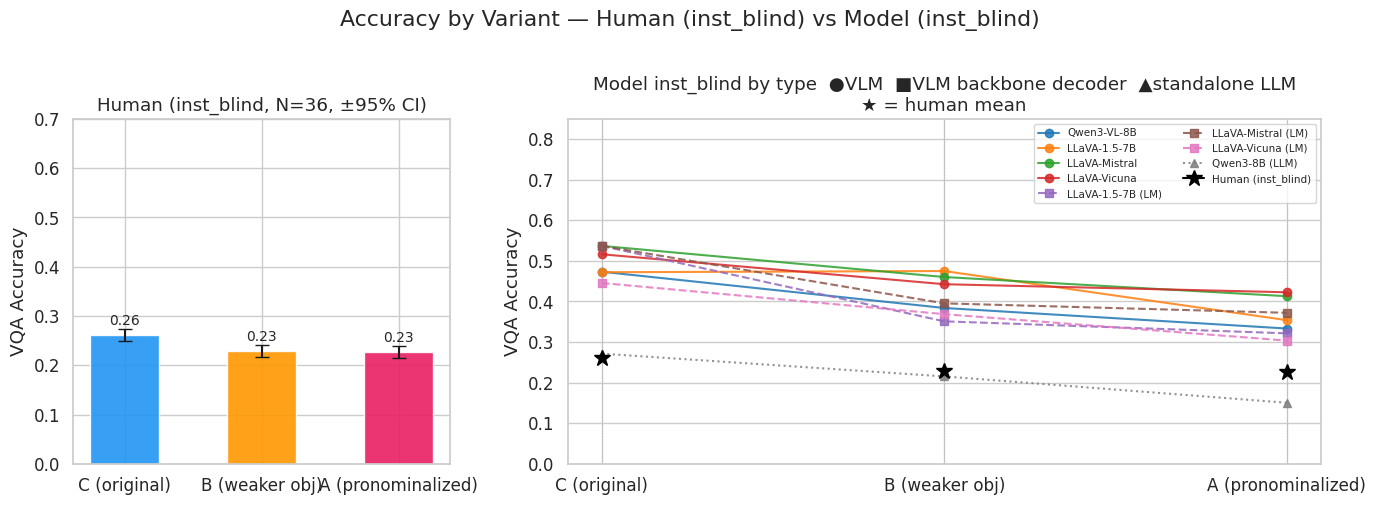

,Human (inst_blind),VLM mean,VLM backbone decoder mean,standalone LLM mean,Human→VLM Δ
Variant,,,,,
C,0.262,0.500,0.506,0.271,0.238
B,0.229,0.440,0.372,0.215,0.211
A,0.227,0.381,0.332,0.150,0.154


In [6]:
# Accuracy by variant — human (inst_blind) + all model types (inst_blind)
from collections import defaultdict

_CT      = {'question': 'C', 'weaker_object': 'B', 'pronominalized': 'A'}
_q_ids   = set(df['question_id'].tolist())
_RESULTS = BASE / 'evaluation/logits'

MODEL_GROUPS = {
    'vlm': {
        'dir': _RESULTS / 'pretrained',
        'models': {
            'Qwen3-VL-8B':   'Qwen3-VL-8B-Instruct',
            'LLaVA-1.5-7B':  'llava-1.5-7b-hf',
            'LLaVA-Mistral': 'llava-v1.6-mistral-7b-hf',
            'LLaVA-Vicuna':  'llava-v1.6-vicuna-7b-hf',
        },
        'linestyle': '-',  'marker': 'o',
    },
    'lm_decoder': {
        'dir': _RESULTS / 'lm_decoder/pretrained',
        'models': {
            'LLaVA-1.5-7B\n(LM)':  'llava-1.5-7b-hf',
            'LLaVA-Mistral\n(LM)': 'llava-v1.6-mistral-7b-hf',
            'LLaVA-Vicuna\n(LM)':  'llava-v1.6-vicuna-7b-hf',
        },
        'linestyle': '--', 'marker': 's',
    },
    'backbone': {
        'dir': _RESULTS / 'backbone/pretrained',
        'models': {
            'Qwen3-8B\n(LLM)': 'Qwen3-8B',
        },
        'linestyle': ':', 'marker': '^',
    },
}

# Load per-variant means for all models (inst_blind)
_acc = {}  # (group, label) → {var: mean_acc}
for gname, ginfo in MODEL_GROUPS.items():
    for label, mdir in ginfo['models'].items():
        path = ginfo['dir'] / mdir / 'vqa_1k_control_inst_blind.jsonl'
        if not path.exists(): continue
        raw = defaultdict(list)
        for line in open(path):
            ex = json.loads(line)
            qid = int(ex['question_id'])
            if qid not in _q_ids: continue
            gt = mapper.get_answers(qid)
            ga = ex.get('generated_answers', {})
            for ct, var in _CT.items():
                ans = _clean_answer(ga.get(ct, ''))
                if ans and gt:
                    raw[var].append(vqa_accuracy(ans, gt))
        _acc[(gname, label)] = {var: float(np.mean(v)) if v else np.nan
                                 for var, v in raw.items()}

# Human stats
n_participants = df['participant'].nunique()
acc_var = df.groupby('variant')['accuracy'].agg(['mean', 'sem']).loc[VARIANT_ORDER]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1, 2]})

# Left: human bar chart with CI
ax = axes[0]
bars = ax.bar(
    [VARIANT_LABELS[v] for v in VARIANT_ORDER],
    acc_var['mean'], yerr=acc_var['sem'] * 1.96,
    color=[VARIANT_COLORS[v] for v in VARIANT_ORDER],
    capsize=5, width=0.5, edgecolor='white', alpha=0.9
)
for bar, (_, row) in zip(bars, acc_var.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, row['mean'] + 0.015,
            f"{row['mean']:.2f}", ha='center', va='bottom', fontsize=10)
ax.set_ylabel('VQA Accuracy')
ax.set_title(f'Human (inst_blind, N={n_participants}, ±95% CI)')
ax.set_ylim(0, 0.7)

# Right: line plot for all model types (inst_blind)
ax = axes[1]
x_pos  = np.arange(len(VARIANT_ORDER))
cmap   = plt.get_cmap('tab10')
color_idx = 0

for gname, ginfo in MODEL_GROUPS.items():
    ls = ginfo['linestyle']
    mk = ginfo['marker']
    for label, mdir in ginfo['models'].items():
        key = (gname, label)
        if key not in _acc: continue
        means = [_acc[key].get(var, np.nan) for var in VARIANT_ORDER]
        if all(np.isnan(m) for m in means): continue
        short = label.replace('\n', ' ')
        color = cmap(color_idx % 10)
        ax.plot(x_pos, means, linestyle=ls, marker=mk, color=color,
                label=short, linewidth=1.5, markersize=6, alpha=0.85)
        color_idx += 1

# Human mean as star markers per variant
for i, var in enumerate(VARIANT_ORDER):
    ax.axvline(i, color='gray', lw=0.4, ls='--', alpha=0.3)
    ax.plot(i, acc_var.loc[var, 'mean'], marker='*', markersize=12,
            color='black', zorder=5,
            label='Human (inst_blind)' if i == 0 else '_nolegend_')

ax.set_xticks(x_pos)
ax.set_xticklabels([VARIANT_LABELS[v] for v in VARIANT_ORDER])
ax.set_ylabel('VQA Accuracy')
ax.set_title('Model inst_blind by type  ●VLM  ■VLM backbone decoder  ▲standalone LLM\n★ = human mean')
ax.set_ylim(0, 0.85)
ax.legend(fontsize=7.5, ncol=2, loc='upper right', framealpha=0.8)

plt.suptitle(f'Accuracy by Variant — Human (inst_blind) vs Model (inst_blind)', y=1.01)
plt.tight_layout()
plt.show()

# ── Summary table: human + model group accuracy by variant ───────────────────
table_rows = []
for var in VARIANT_ORDER:
    row = {'Variant': var, 'Human (inst_blind)': round(acc_var.loc[var, 'mean'], 3)}
    for gname_key, ginfo in MODEL_GROUPS.items():
        vals = [_acc[(gname_key, lbl)][var]
                for lbl in ginfo['models']
                if (gname_key, lbl) in _acc and not np.isnan(_acc[(gname_key, lbl)].get(var, np.nan))]
        gname_display = {'vlm': 'VLM', 'lm_decoder': 'VLM backbone decoder', 'backbone': 'standalone LLM'}[gname_key]
        row[f'{gname_display} mean'] = round(np.mean(vals), 3) if vals else np.nan
    table_rows.append(row)

tbl = pd.DataFrame(table_rows).set_index('Variant')
tbl['Human→VLM Δ'] = (tbl['VLM mean'] - tbl['Human (inst_blind)']).round(3)
display(tbl)

In [7]:
# Per-participant accuracy by variant
pp = df.groupby(['participant','variant'])['accuracy'].mean().unstack()[VARIANT_ORDER]
print('Per-participant accuracy:')
print(pp.round(3))
print(f'\nMean degradation C→A: {(pp["C"] - pp["A"]).mean():.3f}')

Per-participant accuracy:
variant          C      B      A
participant                     
0S9EIHUY     0.251  0.274  0.245
0X4B4L3T     0.192  0.159  0.162
1UB7WNAM     0.304  0.230  0.195
3BN3ZBUX     0.248  0.215  0.189
85M7GIDP     0.260  0.239  0.209
8HLCRUY1     0.280  0.283  0.248
BEK0Y4W3     0.204  0.195  0.236
BTTWUQG4     0.313  0.239  0.198
DPCN9S37     0.251  0.171  0.198
DYAN3RF8     0.289  0.212  0.212
EN84KWE9     0.242  0.201  0.215
FG80C8QR     0.242  0.251  0.198
FLWP3ZF7     0.236  0.206  0.260
FXDCPFHM     0.295  0.248  0.295
FYXQSR7I     0.292  0.271  0.251
HB857QDA     0.248  0.310  0.251
HGIX7HE0     0.274  0.192  0.162
IM2K4RKB     0.189  0.174  0.153
IR1A0UYG     0.274  0.212  0.245
IV0PL083     0.345  0.289  0.289
J09HHJXK     0.242  0.233  0.251
J0OU3FTE     0.319  0.248  0.239
JOJCF28V     0.345  0.271  0.257
K8VD3TYB     0.209  0.233  0.254
MPOMQQNU     0.283  0.260  0.283
NFZJ7A7N     0.257  0.221  0.227
NVF556XP     0.183  0.147  0.165
O23790AV     0.28

## 2. Confidence by Variant

Confidence (1-5) by variant:
          mean   sem
variant             
C        3.138  0.02
B        3.123  0.02
A        2.989  0.02


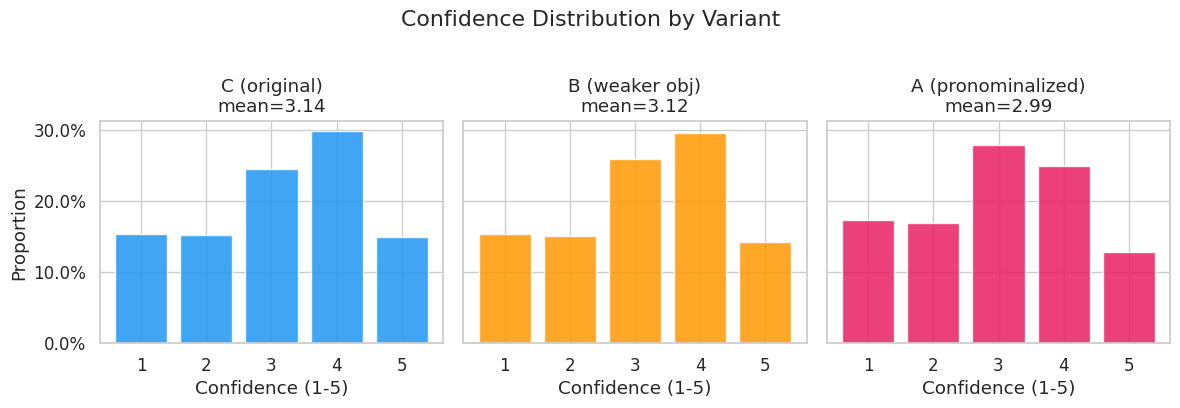

In [8]:
conf_var = df.groupby('variant')['confidence'].agg(['mean','sem'])
conf_var = conf_var.loc[VARIANT_ORDER]
print('Confidence (1-5) by variant:')
print(conf_var.round(3))

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, var in zip(axes, VARIANT_ORDER):
    sub = df[df['variant'] == var]['confidence']
    counts = sub.value_counts().sort_index()
    ax.bar(counts.index, counts.values / counts.sum(),
           color=VARIANT_COLORS[var], edgecolor='white', alpha=0.85)
    ax.set_title(f'{VARIANT_LABELS[var]}\nmean={sub.mean():.2f}')
    ax.set_xlabel('Confidence (1-5)')
    ax.set_xticks([1,2,3,4,5])
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].set_ylabel('Proportion')
plt.suptitle('Confidence Distribution by Variant', y=1.02)
plt.tight_layout()
plt.show()

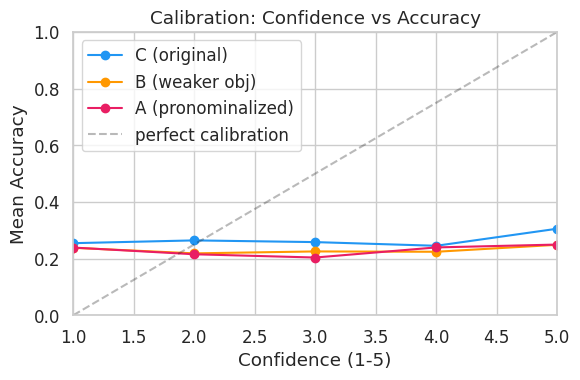

In [9]:
# Accuracy vs confidence (calibration check)
cal = df.groupby(['variant','confidence'])['accuracy'].mean().unstack(level=0)
fig, ax = plt.subplots(figsize=(6,4))
for var in VARIANT_ORDER:
    if var in cal.columns:
        ax.plot(cal.index, cal[var], marker='o', label=VARIANT_LABELS[var],
                color=VARIANT_COLORS[var])
ax.plot([1,5],[0,1], 'k--', alpha=0.3, label='perfect calibration')
ax.set_xlabel('Confidence (1-5)')
ax.set_ylabel('Mean Accuracy')
ax.set_title('Calibration: Confidence vs Accuracy')
ax.legend()
ax.set_xlim(1,5); ax.set_ylim(0,1)
plt.tight_layout()
plt.show()

## 3. Response Time

Response time (seconds) by variant:
         median  mean
variant              
A          4.16  8.78
B          4.20  6.19
C          4.16  6.87


/tmp/ipykernel_318559/897593536.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, labels=[VARIANT_LABELS[v] for v in VARIANT_ORDER],


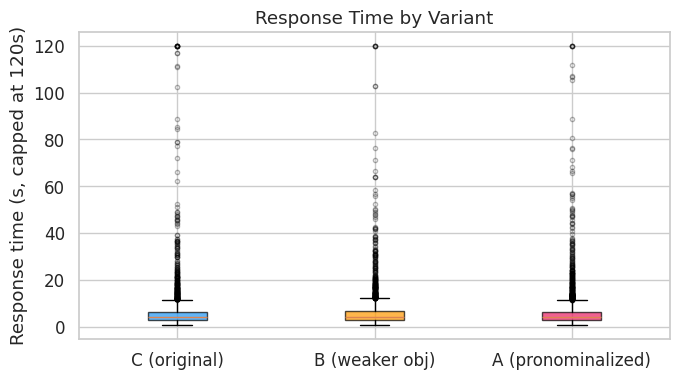

In [10]:
# Cap outliers at 120s for visualization
df['time_s_cap'] = df['time_s'].clip(upper=120)

time_var = df.groupby('variant')['time_s'].agg(['median','mean'])
print('Response time (seconds) by variant:')
print(time_var.round(2))

fig, ax = plt.subplots(figsize=(7, 4))
data_plot = [df[df['variant']==v]['time_s_cap'].values for v in VARIANT_ORDER]
bp = ax.boxplot(data_plot, labels=[VARIANT_LABELS[v] for v in VARIANT_ORDER],
                patch_artist=True, showfliers=True,
                flierprops=dict(marker='.', alpha=0.3))
for patch, var in zip(bp['boxes'], VARIANT_ORDER):
    patch.set_facecolor(VARIANT_COLORS[var])
    patch.set_alpha(0.7)
ax.set_ylabel('Response time (s, capped at 120s)')
ax.set_title('Response Time by Variant')
plt.tight_layout()
plt.show()

In [11]:
# Response time by session
time_sess = df.groupby(['session','variant'])['time_s'].median().unstack()[VARIANT_ORDER]
print('Median response time (s) by session × variant:')
print(time_sess.round(2))

Median response time (s) by session × variant:
variant     C     B     A
session                  
1        4.72  4.61  4.39
2        4.36  4.07  4.05
3        3.82  4.16  3.65


## 4. Accuracy by Entity Type and Op

In [12]:
# ── Accuracy by entity group — all model groups (inst_blind) ─────────────────
from collections import defaultdict as _dd

_CT    = {'question': 'C', 'weaker_object': 'B', 'pronominalized': 'A'}
_q_ids = set(df['question_id'].tolist())

ALL_MODEL_GROUPS = {
    'VLM': {
        'dir': BASE / 'evaluation/logits/pretrained',
        'models': {
            'Qwen3-VL-8B': 'Qwen3-VL-8B-Instruct',
            'LLaVA-1.5-7B': 'llava-1.5-7b-hf',
            'LLaVA-Mistral': 'llava-v1.6-mistral-7b-hf',
            'LLaVA-Vicuna':  'llava-v1.6-vicuna-7b-hf',
        },
    },
    'VLM backbone decoder': {
        'dir': BASE / 'evaluation/logits/lm_decoder/pretrained',
        'models': {
            'LLaVA-1.5 (LM)':   'llava-1.5-7b-hf',
            'LLaVA-Mistral (LM)':'llava-v1.6-mistral-7b-hf',
            'LLaVA-Vicuna (LM)': 'llava-v1.6-vicuna-7b-hf',
        },
    },
    'standalone LLM': {
        'dir': BASE / 'evaluation/logits/backbone/pretrained',
        'models': {
            'Qwen3-8B': 'Qwen3-8B',
        },
    },
}
GROUP_COLORS = {'VLM': '#E91E63', 'VLM backbone decoder': '#2196F3', 'standalone LLM': '#FF9800'}

_ent_map = df[['question_id','ent']].drop_duplicates().set_index('question_id')['ent']

# Load per-model per-question accuracy, then compute group means per entity
group_ent_acc = {}   # gname → ent → variant → mean_acc
group_q_acc   = {}   # gname → per-question DataFrame (mean across group models)

for gname, ginfo in ALL_MODEL_GROUPS.items():
    model_dfs = []
    for label, mdir in ginfo['models'].items():
        path = ginfo['dir'] / mdir / 'vqa_1k_control_inst_blind.jsonl'
        if not path.exists(): continue
        _raw = _dd(lambda: _dd(list))
        for line in open(path):
            ex  = json.loads(line)
            qid = int(ex['question_id'])
            if qid not in _q_ids: continue
            gt  = mapper.get_answers(qid)
            ga  = ex.get('generated_answers', {})
            for ct, var in _CT.items():
                ans = _clean_answer(ga.get(ct, ''))
                if ans and gt:
                    _raw[qid][var].append(vqa_accuracy(ans, gt))
        rows_m = [{'question_id': qid,
                   **{var: float(np.mean(_raw[qid][var])) if _raw[qid][var] else np.nan
                      for var in VARIANT_ORDER}}
                  for qid in _q_ids]
        model_dfs.append(pd.DataFrame(rows_m).set_index('question_id'))

    if not model_dfs: continue
    # Mean across models in the group
    grp_mean = pd.concat(model_dfs).groupby(level=0).mean()
    group_q_acc[gname] = grp_mean

    # Per entity-group mean
    grp2 = grp_mean.join(_ent_map)
    group_ent_acc[gname] = grp2.groupby('ent')[VARIANT_ORDER].mean()

# Human accuracy per original entity type
acc_ent = df.groupby(['ent','variant'])['accuracy'].mean().unstack()[VARIANT_ORDER]
ENT_ORDER = sorted(acc_ent.index.tolist())
acc_ent = acc_ent.reindex(ENT_ORDER)

print('Groups loaded:', list(group_ent_acc.keys()))

# Question count and yes/no count per entity
ent_n = df[df['variant'] == 'C'].groupby('ent')['question_id'].nunique().rename('N')

# Yes/no questions: look up answer_type from VQA annotations
qid_to_ent = df[df['variant'] == 'C'].drop_duplicates('question_id').set_index('question_id')['ent']
yesno_counts = {}
for qid, ent in qid_to_ent.items():
    atype = mapper.annotations.get(int(qid), {}).get('answer_type', '')
    if atype == 'yes/no':
        yesno_counts[ent] = yesno_counts.get(ent, 0) + 1
ent_yesno = pd.Series(yesno_counts, name='yes/no').reindex(ENT_ORDER).fillna(0).astype(int)

display_ent = acc_ent.round(3).join(ent_n).join(ent_yesno)

# Add total row: mean for C/B/A, sum for N and yes/no
total = pd.Series({
    'C':      display_ent['C'].mean(),
    'B':      display_ent['B'].mean(),
    'A':      display_ent['A'].mean(),
    'N':      display_ent['N'].sum(),
    'yes/no': display_ent['yes/no'].sum(),
}, name='Total')
display_ent = pd.concat([display_ent, total.to_frame().T])
display_ent[['N','yes/no']] = display_ent[['N','yes/no']].astype(object)  # allow mixed int/float
display_ent.loc['Total', ['N','yes/no']] = display_ent.loc['Total', ['N','yes/no']].astype(int)

print('\nHuman accuracy by entity type × variant:')
print(display_ent.round(3)) 

# ── Question counts per entity group (for plot labels) ────────────────────
ent_n  = df[df.variant == 'C'].groupby('ent')['question_id'].nunique().to_dict()
n_qids = df['question_id'].nunique()
print(f'Total qids in human study: {n_qids}')
print(f'Questions per entity: {ent_n}')

Groups loaded: ['VLM', 'VLM backbone decoder', 'standalone LLM']

Human accuracy by entity type × variant:
             C      B      A     N yes/no
animal   0.372  0.318  0.313  17.0    6.0
food     0.345  0.318  0.319  16.0    5.0
object   0.222  0.199  0.152  27.0    4.0
other    0.203  0.211  0.253   9.0    2.0
person   0.220  0.179  0.202  26.0    6.0
place    0.420  0.319  0.402   5.0    2.0
product  0.207  0.180  0.139   5.0    0.0
text     0.000  0.000  0.000   4.0    0.0
vehicle  0.262  0.241  0.215   4.0    1.0
Total    0.250  0.218  0.222   113     26
Total qids in human study: 113
Questions per entity: {'animal': 17, 'food': 16, 'object': 27, 'other': 9, 'person': 26, 'place': 5, 'product': 5, 'text': 4, 'vehicle': 4}


In [13]:
# ── Grouped bar: human + VLM / VLM backbone decoder / Backbone per entity group ─────────
ent_order = ENT_ORDER
x         = np.arange(len(ent_order))
srcs      = [('Human', None, '#333333')] + [(g, None, GROUP_COLORS[g]) for g in ALL_MODEL_GROUPS]
n_src     = len(srcs)
w         = 0.7 / n_src
offsets   = np.linspace(-(n_src-1)/2, (n_src-1)/2, n_src) * w

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax_i, var in enumerate(VARIANT_ORDER):
    ax = axes[ax_i]
    for (label, _, color), offset in zip(srcs, offsets):
        if label == 'Human':
            vals = [acc_ent.loc[e, var] if e in acc_ent.index else np.nan for e in ent_order]
        else:
            mea = group_ent_acc.get(label, pd.DataFrame())
            vals = [mea.loc[e, var] if e in mea.index else np.nan for e in ent_order]
        ax.bar(x + offset, vals, w, color=color, alpha=0.85, edgecolor='white',
               label=label if ax_i == 0 else '_nolegend_')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{e}\n(n={ent_n.get(e,0)})' for e in ent_order],
                     rotation=30, ha='right')
    ax.set_title(f'Variant {var} — {VARIANT_LABELS[var]}')
    ax.set_ylim(0, 1)
    if ax_i == 0:
        ax.set_ylabel('VQA Accuracy')

axes[0].legend(fontsize=9, loc='upper right')
plt.suptitle(f'Accuracy by Entity Group — Human (inst_blind) vs Model Groups (inst_blind)  [n={n_qids} qids]', y=1.01)
plt.tight_layout()
plt.show()

# ── Degradation C→A: human + 3 model groups per entity ───────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
human_deg = (acc_ent['C'] - acc_ent['A']).reindex(ent_order)

all_degs = [('Human', human_deg, '#333333')] + [
    (gname, (group_ent_acc[gname]['C'] - group_ent_acc[gname]['A']).reindex(ent_order),
     GROUP_COLORS[gname])
    for gname in ALL_MODEL_GROUPS if gname in group_ent_acc
]
n    = len(all_degs)
w    = 0.7 / n
offs = np.linspace(-(n-1)/2, (n-1)/2, n) * w

for (label, deg_vals, color), off in zip(all_degs, offs):
    ax.bar(x + off, deg_vals, w, color=color, alpha=0.85,
           edgecolor='white', label=label)

ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
    ax.set_xticklabels([f'{e}\n(n={ent_n.get(e,0)})' for e in ent_order],
                     rotation=30, ha='right')
ax.set_ylabel('Accuracy drop C → A')
ax.set_title('Degradation C→A by Entity Group — Human vs Model Groups')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


IndentationError: unexpected indent (234975179.py, line 52)

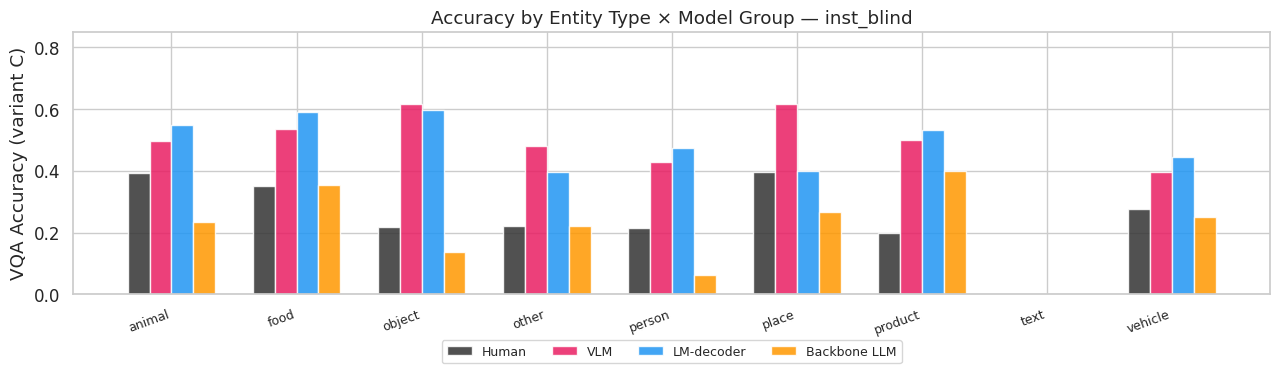

In [ ]:
# ── Accuracy by entity type × model group (variant C, inst_blind) ────────────
# X-axis: entity types  |  bars: model groups (Human / VLM / VLM backbone decoder / Backbone)
group_order  = ['Human'] + list(ALL_MODEL_GROUPS.keys())
GROUP_COLORS_EXT = {'Human': '#333333', **GROUP_COLORS}

x        = np.arange(len(ENT_ORDER))
n_groups = len(group_order)
w        = 0.7 / n_groups
offsets  = np.linspace(-(n_groups-1)/2, (n_groups-1)/2, n_groups) * w

fig, ax = plt.subplots(figsize=(13, 4))
for gname, offset in zip(group_order, offsets):
    if gname == 'Human':
        vals = [acc_ent.loc[e, 'C'] if e in acc_ent.index else np.nan for e in ENT_ORDER]
    else:
        mea  = group_ent_acc.get(gname, pd.DataFrame())
        vals = [mea.loc[e, 'C'] if e in mea.index else np.nan for e in ENT_ORDER]
    ax.bar(x + offset, vals, w, color=GROUP_COLORS_EXT[gname],
           alpha=0.85, edgecolor='white', label=gname)

ax.set_xticks(x)
ax.set_xticklabels([f'{e}\n(n={ent_n.get(e,0)})' for e in ENT_ORDER],
              fontsize=9, rotation=20, ha='right')
ax.set_ylabel('VQA Accuracy (variant C)')
ax.set_title(f'Accuracy by Entity Type × Model Group — inst_blind  (n={n_qids} qids)')
ax.set_ylim(0, 0.85)
ax.legend(fontsize=9, ncols=4, loc='upper center',bbox_to_anchor=(0.5, -0.15))
# ax.axhline(0.5, color='gray', ls='--', lw=0.7)
plt.tight_layout()
plt.show()

## 5. Question-Level Difficulty

In [ ]:
# Human difficulty h(q) per variant = 1 - accuracy
q_acc = df.groupby(['question_id','variant'])['accuracy'].mean().unstack()[VARIANT_ORDER]
q_acc['h_C'] = 1 - q_acc['C']
q_acc['degradation'] = q_acc['C'] - q_acc['A']

# Load v4 metadata for signal_score
s4 = pd.read_csv(BASE / 'experiment/s2_v4/s4.csv')[['question_id', 'acc_original', 'signal_score']]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution of per-question accuracy
ax = axes[0]
for var in VARIANT_ORDER:
    ax.hist(q_acc[var].dropna(), bins=20, alpha=0.5,
            label=VARIANT_LABELS[var], color=VARIANT_COLORS[var])
ax.set_xlabel('Per-question accuracy')
ax.set_ylabel('Number of questions')
ax.set_title('Distribution of Question Accuracy by Variant')
ax.legend()

# Human accuracy (inst_blind) vs model inst_blind accuracy (acc_original = pilot model acc)
ax = axes[1]
q_merged = q_acc.reset_index().merge(s4, on='question_id', how='inner')
sc = ax.scatter(q_merged['acc_original'], q_merged['C'],
                c=q_merged['signal_score'], cmap='RdYlGn', alpha=0.6, s=25)
plt.colorbar(sc, ax=ax, label='signal_score')
ax.set_xlabel('Model blind accuracy (acc_original, pilot)')
ax.set_ylabel('Human accuracy (inst_blind, variant C)')
ax.set_title('Human (inst_blind) vs Model Blind Accuracy (per question)')
r = q_merged[['acc_original', 'C']].dropna().corr().iloc[0, 1]
ax.text(0.05, 0.9, f'r = {r:.3f}', transform=ax.transAxes, fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
# Enrich with question text (from s4 = s2_v4, variant C)
q_lookup = {e['question_id']: e['question_en']
            for e in json.load(open(BASE/'experiment/s2_v4/s4_question.json'))}

q_acc_full = q_acc.reset_index().copy()
q_acc_full['question_en'] = q_acc_full['question_id'].map(q_lookup)

print('10 hardest (C):')
for _, row in q_acc_full.nsmallest(10,'C').iterrows():
    print(f"  {row['question_id']} acc={row['C']:.2f} deg={row['degradation']:.2f}  {row['question_en']}")

print('\n10 easiest (C):')
for _, row in q_acc_full.nlargest(10,'C').iterrows():
    print(f"  {row['question_id']} acc={row['C']:.2f} deg={row['degradation']:.2f}  {row['question_en']}")

10 hardest (C):
  1342072 acc=0.00 deg=0.00  What kind of information does the yellow and white book look like it contains?
  73521003 acc=0.00 deg=0.00  What location is the luggage at?
  91236000 acc=0.00 deg=-0.01  What formation are the aircraft in?
  121442004 acc=0.00 deg=-0.09  How many kids have glasses?
  121839003 acc=0.00 deg=0.00  What are the ladies wearing on their head's?
  169996009 acc=0.00 deg=0.00  What is the name of the store closest to the van?
  187196001 acc=0.00 deg=0.00  What does the shirt say?
  211837003 acc=0.00 deg=0.00  How many zebra are in the picture?
  213359003 acc=0.00 deg=-0.04  What does the man's gesture mean?
  226154000 acc=0.00 deg=0.00  What language is the writing at the top of the bus in?

10 easiest (C):
  199876000 acc=1.00 deg=0.00  Are these women friends?
  219492002 acc=1.00 deg=0.00  Are cats really afraid to get into water?
  335047002 acc=1.00 deg=0.00  Is there a hot dog in there?
  374111001 acc=1.00 deg=0.00  Are the chips fres

## 6. Human vs Model Alignment

In [14]:
# Spearman / Pearson / Kendall τ — human (inst_blind) vs model (inst_blind) per question
from scipy.stats import pearsonr, spearmanr, kendalltau

results = []
for var in VARIANT_ORDER:
    h_var = q_acc[var].dropna().rename('human')
    for label, mdf in model_q_acc.items():
        merged = h_var.reset_index().merge(
            mdf[var].dropna().reset_index(), on='question_id'
        ).dropna()
        if len(merged) < 5: continue
        r,   _ = pearsonr( merged['human'], merged[var])
        rho, _ = spearmanr(merged['human'], merged[var])
        tau, _ = kendalltau(merged['human'], merged[var])
        results.append({'model': label, 'type': MODEL_TYPE.get(label, '?'), 'variant': var,
                        'pearson_r': r, 'spearman_rho': rho,
                        'kendall_tau': tau, 'n': len(merged)})

rdf = pd.DataFrame(results)

# Print grouped by model type
print('Correlation: human (inst_blind) accuracy vs model (inst_blind) accuracy per question')
print('(Pearson r | Spearman ρ | Kendall τ)')
print(f'{"model":22}  {"type":12}  {"C":>22}  {"B":>22}  {"A":>22}')
print('-' * 105)
for mtype in ['VLM', 'VLM backbone decoder', 'standalone LLM']:
    for label in model_q_acc:
        if MODEL_TYPE.get(label) != mtype: continue
        parts = []
        for var in VARIANT_ORDER:
            sub = rdf[(rdf.model == label) & (rdf.variant == var)]
            if sub.empty:
                parts.append(f'{"n/a":>22}')
            else:
                r = sub.iloc[0]
                parts.append(f'{r.pearson_r:+.3f} {r.spearman_rho:+.3f} {r.kendall_tau:+.3f}')
        print(f'{label:22}  {mtype:12}  {"  ".join(parts)}')
    print()

NameError: name 'q_acc' is not defined

In [ ]:
# Summary: mean accuracy + degradation C→A (inst_blind models vs human inst_blind)
n_p = df['participant'].nunique()
print(f'{"":25}  {"type":12}  {"C":>6} {"A":>6} {"C→A deg":>8}')
print('-' * 62)
for mtype in ['VLM', 'VLM backbone decoder', 'standalone LLM']:
    for label, mdf in model_q_acc.items():
        if MODEL_TYPE.get(label) != mtype: continue
        c = mdf['C'].mean(); a = mdf['A'].mean()
        print(f'{label:25}  {mtype:12}  {c:.3f}  {a:.3f}  {c-a:+.3f}')
    print()
h_c = df[df.variant=="C"]["accuracy"].mean()
h_a = df[df.variant=="A"]["accuracy"].mean()
print(f'{f"Human (inst_blind, N={n_p})":25}  {"—":12}  {h_c:.3f}  {h_a:.3f}  {h_c-h_a:+.3f}')

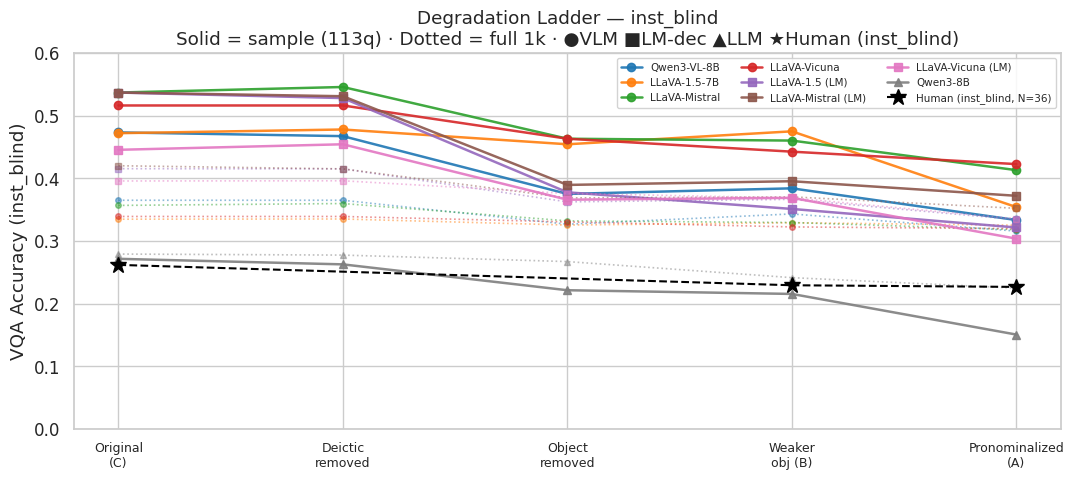

question  deictic_removed  \
Group      Model                                                 
vlm        Qwen3-VL-8B                  0.473            0.467   
           LLaVA-1.5-7B                 0.472            0.478   
           LLaVA-Mistral                0.537            0.546   
           LLaVA-Vicuna                 0.516            0.516   
lm_decoder LLaVA-1.5 (LM)               0.537            0.528   
           LLaVA-Mistral (LM)           0.537            0.531   
           LLaVA-Vicuna (LM)            0.445            0.454   
backbone   Qwen3-8B                     0.271            0.263   
Human      Human (inst_blind, N=36)     0.262              NaN   

                                     object_removed  weaker_object  \
Group      Model                                                     
vlm        Qwen3-VL-8B                        0.375          0.384   
           LLaVA-1.5-7B                       0.454          0.475   
           LLaVA-Mistral                      0.463          0.460   
           LLaVA-Vicuna                       0.463          0.442   
lm_decoder LLaVA-1.5 (LM)                     0.378          0.351   
           LLaVA-Mistral (LM)                 0.389          0.395   
           LLaVA-Vicuna (LM)                  0.366          0.369   
backbone   Qwen3-8B                           0.221          0.215   
Human      Human (inst_blind, N=36)             NaN          0.229   

                                     pronominalized  C→A drop  
Group      Model                                               
vlm        Qwen3-VL-8B                        0.333     0.140  
           LLaVA-1.5-7B                       0.354     0.118  
           LLaVA-Mistral                      0.413     0.124  
           LLaVA-Vicuna                       0.423     0.093  
lm_decoder LLaVA-1.5 (LM)                     0.321     0.216  
           LLaVA-Mistral (LM)                 0.372     0.165  
           LLaVA-Vicuna (LM)                  0.304     0.141  
backbone   Qwen3-8B                           0.150     0.121  
Human      Human (inst_blind, N=36)           0.227     0.035

In [15]:
# ── Degradation ladder: full 1k (dotted) vs sample (solid) ───────────────────
# inst_blind condition for all model types + human (inst_blind, 3 points: C/B/A)
from collections import defaultdict as _dd

CONTROL_TYPES  = ['question','deictic_removed','object_removed','weaker_object','pronominalized']
CT_LABELS      = ['Original\n(C)','Deictic\nremoved','Object\nremoved','Weaker\nobj (B)','Pronominalized\n(A)']
HUMAN_CT_IDX   = {'C': 0, 'B': 3, 'A': 4}

LOGIT_BASE = BASE / 'evaluation/logits'
MODEL_GROUPS_LADDER = {
    'vlm': {
        'dir': LOGIT_BASE / 'pretrained',
        'marker': 'o', 'models': {
            'Qwen3-VL-8B':    'Qwen3-VL-8B-Instruct',
            'LLaVA-1.5-7B':   'llava-1.5-7b-hf',
            'LLaVA-Mistral':  'llava-v1.6-mistral-7b-hf',
            'LLaVA-Vicuna':   'llava-v1.6-vicuna-7b-hf',
        }
    },
    'lm_decoder': {
        'dir': LOGIT_BASE / 'lm_decoder/pretrained',
        'marker': 's', 'models': {
            'LLaVA-1.5 (LM)':   'llava-1.5-7b-hf',
            'LLaVA-Mistral (LM)': 'llava-v1.6-mistral-7b-hf',
            'LLaVA-Vicuna (LM)':  'llava-v1.6-vicuna-7b-hf',
        }
    },
    'backbone': {
        'dir': LOGIT_BASE / 'backbone/pretrained',
        'marker': '^', 'models': {
            'Qwen3-8B': 'Qwen3-8B',
        }
    },
}

def load_ct_acc(model_dir, qid_filter=None):
    path = model_dir / 'vqa_1k_control_inst_blind.jsonl'
    if not path.exists():
        return {}
    ct_acc = _dd(list)
    for line in open(path):
        ex  = json.loads(line)
        qid = int(ex['question_id'])
        if qid_filter and qid not in qid_filter:
            continue
        gt = mapper.get_answers(qid)
        ga = ex.get('generated_answers', {})
        for ct in CONTROL_TYPES:
            ans = _clean_answer(ga.get(ct, ''))
            if ans and gt:
                ct_acc[ct].append(vqa_accuracy(ans, gt))
    return {ct: float(np.mean(v)) for ct, v in ct_acc.items() if v}

sample_qids = set(df['question_id'].tolist())
n_sample = len(sample_qids)
x = np.arange(len(CONTROL_TYPES))

curves = []
for gname, ginfo in MODEL_GROUPS_LADDER.items():
    for label, mdir in ginfo['models'].items():
        mpath = ginfo['dir'] / mdir
        s_acc = load_ct_acc(mpath, qid_filter=sample_qids)
        f_acc = load_ct_acc(mpath, qid_filter=None)
        if not s_acc and not f_acc:
            continue
        s_vals = [s_acc.get(ct, np.nan) for ct in CONTROL_TYPES]
        f_vals = [f_acc.get(ct, np.nan) for ct in CONTROL_TYPES]
        curves.append((label, gname, ginfo['marker'], s_vals, f_vals))

# Human 3-point curve (inst_blind condition)
h_vals = [np.nan] * len(CONTROL_TYPES)
for var, idx in HUMAN_CT_IDX.items():
    h_vals[idx] = df[df.variant == var]['accuracy'].mean()

cmap = plt.get_cmap('tab10')
label_colors = {c[0]: cmap(i % 10) for i, c in enumerate(curves)}
n_p = df['participant'].nunique()

fig, ax = plt.subplots(figsize=(11, 5))

for label, gname, marker, s_vals, f_vals in curves:
    color = label_colors[label]
    ax.plot(x, s_vals, color=color, marker=marker, ls='-',
            linewidth=1.8, markersize=6, alpha=0.9, label=label)
    if any(not np.isnan(v) for v in f_vals):
        ax.plot(x, f_vals, color=color, marker=marker, ls=':',
                linewidth=1.2, markersize=4, alpha=0.5, label='_nolegend_')

h_x = [i for i, v in enumerate(h_vals) if not np.isnan(v)]
h_y = [v for v in h_vals if not np.isnan(v)]
ax.plot(h_x, h_y, color='black', marker='*', ls='--',
        linewidth=1.5, markersize=12, zorder=5,
        label=f'Human (inst_blind, N={n_p})')

ax.set_xticks(x)
ax.set_xticklabels(CT_LABELS, fontsize=9)
ax.set_ylabel('VQA Accuracy (inst_blind)')
ax.set_ylim(0, 0.6)
ax.set_title(
    f'Degradation Ladder — inst_blind\n'
    f'Solid = sample ({n_sample}q) · Dotted = full 1k · ●VLM ■LM-dec ▲LLM ★Human (inst_blind)'
)
ax.legend(fontsize=7.5, ncol=3, loc='upper right', framealpha=0.85)
plt.tight_layout()
plt.show()

# ── Summary table: mean accuracy per (model, control type) ───────────────────
tbl_rows = []
for label, gname, marker, s_vals, f_vals in curves:
    row = {'Model': label, 'Group': gname}
    for ct, sv in zip(CONTROL_TYPES, s_vals):
        row[ct] = round(sv, 3) if not np.isnan(sv) else np.nan
    tbl_rows.append(row)

# Add human row (3 points only: C, B, A)
h_row = {'Model': f'Human (inst_blind, N={n_p})', 'Group': 'Human'}
for ct, idx in HUMAN_CT_IDX.items():
    h_row[CONTROL_TYPES[idx]] = round(h_vals[idx], 3)
tbl_rows.append(h_row)

deg_tbl = pd.DataFrame(tbl_rows).set_index(['Group', 'Model'])
deg_tbl['C→A drop'] = (deg_tbl['question'] - deg_tbl['pronominalized']).round(3)
display(deg_tbl)

## 7. Calibration — Human Confidence vs Model Logprob Confidence

/home/david/miniconda3/envs/aide/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


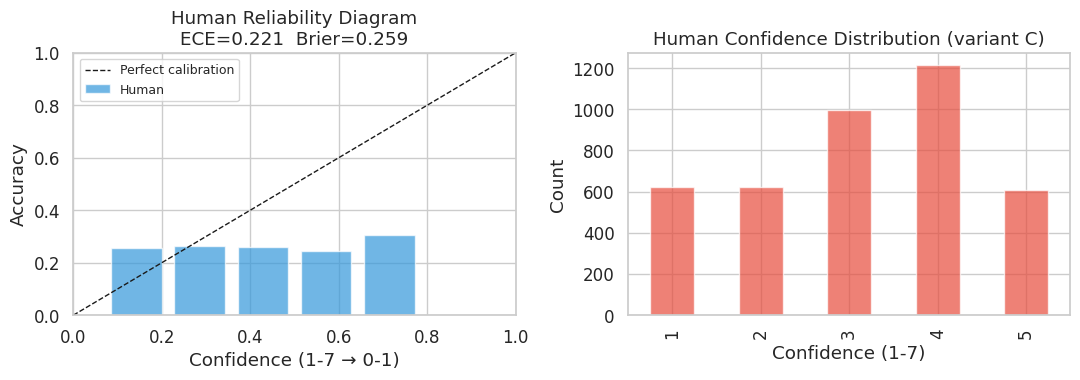

ECE:         0.2208
Brier score: 0.2587
Conf-accuracy Pearson r per participant (mean): 0.043
  0S9EIHUY: r=0.169
  0X4B4L3T: r=-0.078
  1UB7WNAM: r=-0.240
  3BN3ZBUX: r=0.092
  85M7GIDP: r=-0.015
  8HLCRUY1: r=0.012
  BEK0Y4W3: r=0.033
  BTTWUQG4: r=0.071
  DPCN9S37: r=0.236
  DYAN3RF8: r=0.192
  EN84KWE9: r=-0.040
  FG80C8QR: r=-0.076
  FLWP3ZF7: r=-0.063
  FXDCPFHM: r=0.053
  FYXQSR7I: r=0.005
  HB857QDA: r=0.226
  HGIX7HE0: r=-0.087
  IM2K4RKB: r=-0.091
  IR1A0UYG: r=0.082
  IV0PL083: r=0.041
  J09HHJXK: r=0.085
  J0OU3FTE: r=0.085
  JOJCF28V: r=0.396
  K8VD3TYB: r=-0.204
  MPOMQQNU: r=-0.004
  NFZJ7A7N: r=0.069
  NVF556XP: r=0.123
  O23790AV: r=0.100
  OBRNN1JM: r=0.063
  ON7P7X1E: r=0.082
  P3TH5F6I: r=-0.009
  QGIQYWZ6: r=0.097
  TRFMV4H2: r=0.038
  Y2IBXIJX: r=0.224
  ZEF2XJBX: r=-0.171


In [16]:
# ── Human calibration ────────────────────────────────────────────────────────
# Human confidence is on a 1-7 scale; treat conf/7 as probability estimate
# Metrics:
#   Reliability diagram: binned confidence vs mean accuracy
#   ECE (Expected Calibration Error): weighted mean |acc - conf| per bin
#   Brier score: mean((conf/7 - correct)²)

from scipy.stats import pearsonr

cal_df = df[df.variant == 'C'].copy()
cal_df['conf_prob'] = cal_df['confidence'] / 7.0
cal_df['correct']   = cal_df['accuracy'].round().astype(float)  # 0 or 1 for Brier

N_BINS = 7
bins = np.linspace(0, 1, N_BINS + 1)
cal_df['conf_bin'] = pd.cut(cal_df['conf_prob'], bins=bins, labels=False, include_lowest=True)

bin_stats = cal_df.groupby('conf_bin').agg(
    mean_conf=('conf_prob', 'mean'),
    mean_acc=('accuracy', 'mean'),
    n=('accuracy', 'count')
).dropna()

ece   = (bin_stats['n'] / len(cal_df) * (bin_stats['mean_acc'] - bin_stats['mean_conf']).abs()).sum()
brier = ((cal_df['conf_prob'] - cal_df['correct']) ** 2).mean()

# Confidence-accuracy correlation per participant
conf_acc_corr = cal_df.groupby('participant').apply(
    lambda g: pearsonr(g['conf_prob'], g['accuracy'])[0] if len(g) > 5 else np.nan
).dropna()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Reliability diagram
ax = axes[0]
ax.bar(bin_stats['mean_conf'], bin_stats['mean_acc'],
       width=1/N_BINS * 0.8, alpha=0.7, color='#3498db', label='Human')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
ax.set_xlabel('Confidence (1-7 → 0-1)'); ax.set_ylabel('Accuracy')
ax.set_title(f'Human Reliability Diagram\nECE={ece:.3f}  Brier={brier:.3f}')
ax.legend(fontsize=9); ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# Confidence distribution
ax = axes[1]
cal_df['confidence'].value_counts().sort_index().plot(kind='bar', ax=ax, color='#e74c3c', alpha=0.7)
ax.set_xlabel('Confidence (1-7)'); ax.set_ylabel('Count')
ax.set_title(f'Human Confidence Distribution (variant C)')

plt.tight_layout(); plt.show()

print(f'ECE:         {ece:.4f}')
print(f'Brier score: {brier:.4f}')
print(f'Conf-accuracy Pearson r per participant (mean): {conf_acc_corr.mean():.3f}')
for pid, r in conf_acc_corr.items():
    print(f'  {pid}: r={r:.3f}')


In [17]:
# ── Model calibration from logprobs (inst_blind, yes/no questions only) ──────
# For yes/no questions: extract P(yes) from top-5 logprobs of first token
# Use softmax over {yes, no} tokens to get calibrated probability
# ECE and reliability diagram compared to human calibration

import math

def extract_yn_prob(logits_content):
    """Extract P(yes) from top-5 first-token logits. Returns None if yes/no not in top-5."""
    if not logits_content: return None
    top = logits_content[0]['top_logprobs']
    yn_lp = {}
    for t in top:
        tok = t['token'].strip().lower()
        if tok in ('yes', 'no') and tok not in yn_lp:
            yn_lp[tok] = t['logprob']
    if 'yes' not in yn_lp and 'no' not in yn_lp:
        return None
    # softmax over yes/no only
    lp_yes = yn_lp.get('yes', -30.0)
    lp_no  = yn_lp.get('no',  -30.0)
    p_yes = math.exp(lp_yes) / (math.exp(lp_yes) + math.exp(lp_no))
    return p_yes

# Load inst_blind logprobs for yes/no questions
yn_qids = set(df[df.variant == 'C']['question_id'].tolist())
# filter to questions where GT is yes/no
yn_gt_qids = {qid for qid in yn_qids
              if any(a in ('yes','no') for a in (mapper.get_answers(qid) or []))}

model_calib = {}  # label → list of (p_yes, correct)
for label, mdir in MODELS.items():
    path = MODELS[label] / 'vqa_1k_control_inst_blind.jsonl'
    if not path.exists(): continue
    records = []
    for line in open(path):
        ex = json.loads(line)
        qid = int(ex['question_id'])
        if qid not in yn_gt_qids: continue
        gl = ex.get('generated_logits', {}).get('question', {}).get('content')
        p_yes = extract_yn_prob(gl)
        if p_yes is None: continue
        gt  = mapper.get_answers(qid)
        ans = ex.get('generated_answers', {}).get('question', '').strip().lower()
        correct = float(vqa_accuracy(ans, gt)) if gt else np.nan
        if not np.isnan(correct):
            records.append({'p_yes': p_yes, 'correct': correct,
                            'predicted_yes': int(p_yes >= 0.5)})
    model_calib[label] = records
    if records:
        from scipy.stats import pearsonr as _pr
        rdf = pd.DataFrame(records)
        r, _ = _pr(rdf['p_yes'], rdf['correct'])
        print(f'{label}: {len(records)} yes/no questions with logprobs  r(P(yes),correct)={r:.3f}')
    else:
        print(f'{label}: 0 yes/no questions with logprobs')

# Reliability diagrams: human vs models
N_BINS = 5
# Only plot models with actual calibration data
calib_models = [(label, records) for label, records in model_calib.items() if len(records) > 0]
n_models = len(calib_models)
fig, axes = plt.subplots(1, n_models + 1, figsize=(2.5 * (n_models + 1), 4), sharey=True)

# Human (yes/no only)
cal_yn = df[(df.variant == 'C') & df['question_id'].isin(yn_gt_qids)].copy()
cal_yn['conf_prob'] = cal_yn['confidence'] / 7.0
h_bin_stats = cal_yn.groupby(pd.cut(cal_yn['conf_prob'], bins=N_BINS)).agg(
    mean_conf=('conf_prob', 'mean'), mean_acc=('accuracy', 'mean'), n=('accuracy', 'count')
).dropna()
h_ece = (h_bin_stats['n'] / len(cal_yn) * (h_bin_stats['mean_acc'] - h_bin_stats['mean_conf']).abs()).sum()

ax = axes[0]
ax.bar(h_bin_stats['mean_conf'], h_bin_stats['mean_acc'], width=0.15, alpha=0.75, color='#3498db')
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_title(f'Human\nECE={h_ece:.3f}', fontsize=9)
ax.set_ylabel('Accuracy'); ax.set_xlabel('Confidence')
ax.set_xlim(0,1); ax.set_ylim(0,1)

for ax, (label, records) in zip(axes[1:], calib_models):
    rdf_m = pd.DataFrame(records)
    m_bin_stats = rdf_m.groupby(pd.cut(rdf_m['p_yes'], bins=N_BINS)).agg(
        mean_conf=('p_yes', 'mean'), mean_acc=('correct', 'mean'), n=('correct', 'count')
    ).dropna()
    m_ece = (m_bin_stats['n'] / len(rdf_m) * (m_bin_stats['mean_acc'] - m_bin_stats['mean_conf']).abs()).sum()
    m_brier = ((rdf_m['p_yes'] - rdf_m['correct']) ** 2).mean()
    ax.bar(m_bin_stats['mean_conf'], m_bin_stats['mean_acc'], width=0.15, alpha=0.75, color='#e74c3c')
    ax.plot([0,1],[0,1],'k--',lw=1)
    ax.set_title(f'{label}\nECE={m_ece:.3f} Brier={m_brier:.3f}', fontsize=8)
    ax.set_xlabel('P(yes) from logprobs')

plt.suptitle('Calibration: Human confidence vs Model P(yes) — inst_blind, yes/no questions', y=1.02)
plt.tight_layout(); plt.show()
print('Calibration models:', [l for l, _ in calib_models]) 

Qwen3-VL-8B: 26 yes/no questions with logprobs  r(P(yes),correct)=-0.322
LLaVA-1.5-7B: 28 yes/no questions with logprobs  r(P(yes),correct)=-0.131


LLaVA-Mistral: 28 yes/no questions with logprobs  r(P(yes),correct)=-0.080
LLaVA-Vicuna: 28 yes/no questions with logprobs  r(P(yes),correct)=-0.057
InternVL-1B: 26 yes/no questions with logprobs  r(P(yes),correct)=-0.364
InternVL-2B: 26 yes/no questions with logprobs  r(P(yes),correct)=-0.117
InternVL-8B: 26 yes/no questions with logprobs  r(P(yes),correct)=-0.203
LLaVA-1.5 (LM): 26 yes/no questions with logprobs  r(P(yes),correct)=-0.200
LLaVA-Mistral (LM): 27 yes/no questions with logprobs  r(P(yes),correct)=-0.515
LLaVA-Vicuna (LM): 27 yes/no questions with logprobs  r(P(yes),correct)=-0.033


ValueError: x and y must have length at least 2.

Answer agreement rate: human vs model (inst_blind, yes/no, variant C)
             model  agreement  human_yes_rate  model_yes_rate  n
       Qwen3-VL-8B      0.583           0.667           0.417 36
      LLaVA-1.5-7B      0.389           0.667           0.111 36
     LLaVA-Mistral      0.500           0.667           0.278 36
      LLaVA-Vicuna      0.500           0.667           0.278 36
       InternVL-1B      0.417           0.667           0.306 36
       InternVL-2B      0.389           0.667           0.167 36
       InternVL-8B      0.667           0.667           0.722 36
    LLaVA-1.5 (LM)      0.694           0.667           0.528 36
LLaVA-Mistral (LM)      0.528           0.667           0.472 36
 LLaVA-Vicuna (LM)      0.639           0.667           0.806 36
          Qwen3-8B      0.600           0.700           0.700 20


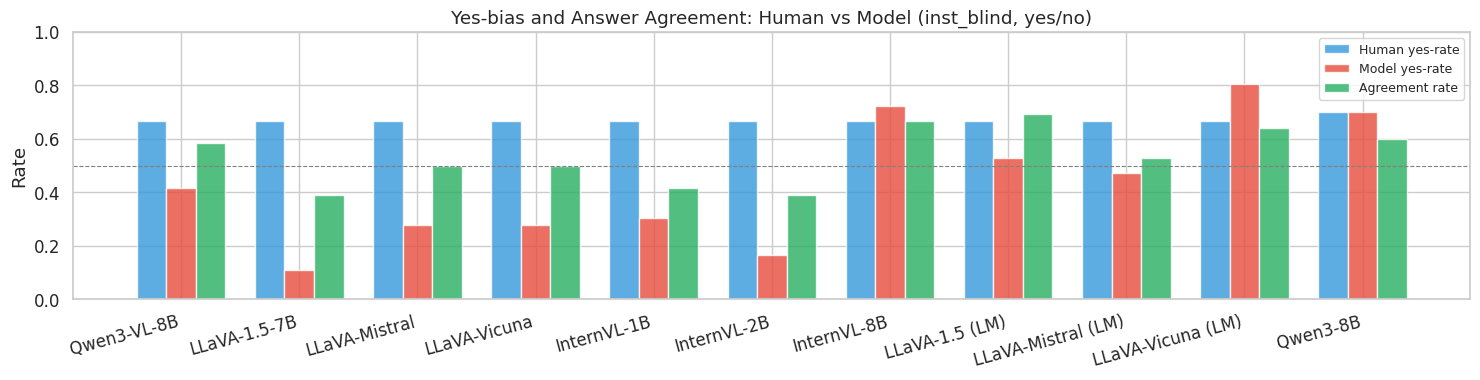

In [ ]:
# ── Answer agreement rate: human vs model (yes/no questions, inst_blind) ─────
# Do human and model give the same answer regardless of GT?
# Measures alignment of priors independent of correctness

# Collapse to question level: human majority vote per question
yn_all = df[(df.variant == 'C') & df['question_id'].isin(yn_gt_qids)].copy()
yn_all['answer_yn'] = yn_all['answer_en'].str.lower().str.strip().map(
    lambda x: x if x in ('yes','no') else None)
yn_all = yn_all.dropna(subset=['answer_yn'])
# majority vote: yes if > 50% of participants said yes, else no
yn_q = (yn_all.groupby('question_id')['answer_yn']
        .apply(lambda s: 'yes' if (s == 'yes').mean() > 0.5 else 'no')
        .reset_index().rename(columns={'answer_yn': 'human_maj'}))

agree_rows = []
for label, records in model_calib.items():
    rec_map = {}  # qid → model answer
    path = MODELS[label] / 'vqa_1k_control_inst_blind.jsonl'
    if path.exists():
        for line in open(path):
            ex = json.loads(line)
            qid = int(ex['question_id'])
            if qid not in yn_gt_qids: continue
            raw = ex.get('generated_answers',{}).get('question','')
            raw = _clean_answer(raw)
            ans = re.sub(r'[^\w]', '', raw.strip().lower())
            if ans in ('yes','no'):
                rec_map[qid] = ans

    model_ser = pd.Series(rec_map, name='model_ans').reset_index().rename(columns={'index':'question_id'})
    merged = yn_q.merge(model_ser, on='question_id', how='inner')
    agree = (merged['human_maj'] == merged['model_ans']).mean()
    h_yes  = (merged['human_maj'] == 'yes').mean()
    m_yes  = (merged['model_ans'] == 'yes').mean()
    agree_rows.append({'model': label, 'agreement': agree,
                       'human_yes_rate': h_yes, 'model_yes_rate': m_yes,
                       'n': len(merged)})

agree_df = pd.DataFrame(agree_rows)
print('Answer agreement rate: human vs model (inst_blind, yes/no, variant C)')
print(agree_df.to_string(index=False, float_format='{:.3f}'.format))

# Yes-bias comparison bar chart
fig, ax = plt.subplots(figsize=(15, 4))
x = np.arange(len(agree_df))
w = 0.25
ax.bar(x - w, agree_df['human_yes_rate'],  w, label='Human yes-rate',  color='#3498db', alpha=0.8)
ax.bar(x,     agree_df['model_yes_rate'],  w, label='Model yes-rate',  color='#e74c3c', alpha=0.8)
ax.bar(x + w, agree_df['agreement'],       w, label='Agreement rate',  color='#27ae60', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(agree_df['model'], rotation=15, ha='right')
ax.set_ylabel('Rate'); ax.set_ylim(0, 1)
ax.set_title('Yes-bias and Answer Agreement: Human vs Model (inst_blind, yes/no)')
ax.axhline(0.5, color='gray', ls='--', lw=0.8)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()